# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [23]:
# Load environment variables
# Standard libraries
import pandas as pd
import numpy as np

df = pd.read_csv('../../05_src/data/fires/forestfires.csv')
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [25]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [28]:
# Define target column
target_column = 'area'

# Define X and y
X = df.drop(columns=[target_column])
y = df[target_column]


In [29]:
print(X.head())
print(y.head())


   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: area, dtype: float64


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify categorical and numerical columns
categorical_features = ['month', 'day']
numerical_features = [col for col in X.columns if col not in categorical_features]

# Define the transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create ColumnTransformer for preproc1
preproc1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Categorical and numerical features
categorical_features = ['month', 'day']
# Select 'ISI' for non-linear transformation
log_transform_features = ['ISI']
# The rest are normal numeric features
standard_scale_features = [col for col in X.columns if col not in categorical_features + log_transform_features]

# Transformers
log_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p, validate=True)),
    ('scaler', StandardScaler())
])

standard_numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# ColumnTransformer for preproc2
preproc2 = ColumnTransformer(
    transformers=[
        ('log_scaled', log_transformer, log_transform_features),
        ('scaled', standard_numeric_transformer, standard_scale_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [39]:
# Pipeline A = preproc1 + baseline
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(steps=[
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10, 20]
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)

rf_best_model = rf_grid.best_estimator_

rf_predictions = rf_best_model.predict(X_test)

from math import sqrt
from sklearn.metrics import mean_squared_error, r2_score

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("\n🔹 Random Forest Regression:")
print(f"Best Params: {rf_grid.best_params_}")
print(f"Test RMSE: {rf_rmse:.4f}")
print(f"Test R^2: {rf_r2:.4f}")










🔹 Random Forest Regression:
Best Params: {'regressor__max_depth': None, 'regressor__n_estimators': 100}
Test RMSE: 109.4046
Test R^2: -0.0154


In [40]:
# Pipeline B = preproc2 + baseline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define pipeline B
pipeline_b = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Ridge())
])

# Hyperparameter grid for Ridge
param_grid = {
    'regressor__alpha': [0.1, 1.0, 10.0]
}

# Grid search CV
grid_search_b = GridSearchCV(pipeline_b, param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid_search_b.fit(X_train, y_train)

# Best model from grid search
best_model_b = grid_search_b.best_estimator_

# Predict on test set
y_pred_b = best_model_b.predict(X_test)

# Calculate metrics
rmse_b = sqrt(mean_squared_error(y_test, y_pred_b))
r2_b = r2_score(y_test, y_pred_b)

print("Pipeline B (preproc2 + Ridge) results:")
print(f"Best alpha: {grid_search_b.best_params_['regressor__alpha']}")
print(f"Test RMSE: {rmse_b:.4f}")
print(f"Test R^2: {r2_b:.4f}")


Pipeline B (preproc2 + Ridge) results:
Best alpha: 10.0
Test RMSE: 108.1272
Test R^2: 0.0082


In [41]:
# Pipeline C = preproc1 + advanced model
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

# Split data (if not done already)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Pipeline C
pipeline_c = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# Hyperparameter grid for tuning
param_grid_c = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth': [3, 5]
}

# Grid search CV
grid_search_c = GridSearchCV(pipeline_c, param_grid_c, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_c.fit(X_train, y_train)

# Best model
best_model_c = grid_search_c.best_estimator_

# Predict and evaluate
y_pred_c = best_model_c.predict(X_test)
rmse_c = sqrt(mean_squared_error(y_test, y_pred_c))
r2_c = r2_score(y_test, y_pred_c)

print("Pipeline C (preproc1 + GradientBoostingRegressor) results:")
print(f"Best params: {grid_search_c.best_params_}")
print(f"Test RMSE: {rmse_c:.4f}")
print(f"Test R^2: {r2_c:.4f}")


Pipeline C (preproc1 + GradientBoostingRegressor) results:
Best params: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 100}
Test RMSE: 112.0336
Test R^2: -0.0648


In [43]:
# Pipeline D = preproc2 + advanced model
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

# If not done already, split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Pipeline D
pipeline_d = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# Hyperparameter grid (same as Pipeline C or customized)
param_grid_d = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth': [3, 5]
}

# GridSearchCV
grid_search_d = GridSearchCV(pipeline_d, param_grid_d, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_d.fit(X_train, y_train)

# Best model
best_model_d = grid_search_d.best_estimator_

# Predictions & evaluation
y_pred_d = best_model_d.predict(X_test)
rmse_d = sqrt(mean_squared_error(y_test, y_pred_d))
r2_d = r2_score(y_test, y_pred_d)

print("Pipeline D (preproc2 + GradientBoostingRegressor) results:")
print(f"Best params: {grid_search_d.best_params_}")
print(f"Test RMSE: {rmse_d:.4f}")
print(f"Test R^2: {r2_d:.4f}")


Pipeline D (preproc2 + GradientBoostingRegressor) results:
Best params: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 100}
Test RMSE: 109.0049
Test R^2: -0.0080


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

# Make sure X, y, preproc1, preproc2 are already defined

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define pipelines
pipelines = {
    'Pipeline A': Pipeline([('preprocessing', preproc1), ('regressor', Ridge())]),
    'Pipeline B': Pipeline([('preprocessing', preproc2), ('regressor', Ridge())]),
    'Pipeline C': Pipeline([('preprocessing', preproc1), ('regressor', GradientBoostingRegressor(random_state=42))]),
    'Pipeline D': Pipeline([('preprocessing', preproc2), ('regressor', GradientBoostingRegressor(random_state=42))]),
}

# Define parameter grids
param_grids = {
    'Pipeline A': {'regressor__alpha': [0.01, 0.1, 1, 10, 100]},
    'Pipeline B': {'regressor__alpha': [0.01, 0.1, 1, 10, 100]},
    'Pipeline C': {
        'regressor__n_estimators': [100, 200, 300, 400],
        'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    },
    'Pipeline D': {
        'regressor__max_depth': [3, 5, 7, 9]
    }
}

results = {}

for name, pipeline in pipelines.items():
    print(f"Running GridSearchCV for {name} ...")
    
    grid = GridSearchCV(
        pipeline, 
        param_grids[name], 
        cv=5, 
        scoring='neg_root_mean_squared_error', 
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'best_params': grid.best_params_,
        'rmse': rmse,
        'r2': r2
    }
    
    print(f"{name} best params: {grid.best_params_}")
    print(f"{name} Test RMSE: {rmse:.4f}")
    print(f"{name} Test R^2: {r2:.4f}")
    print('-' * 30)


import pandas as pd
summary_df = pd.DataFrame(results).T
print(summary_df)


Running GridSearchCV for Pipeline A ...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Pipeline A best params: {'regressor__alpha': 100}
Pipeline A Test RMSE: 108.3514
Pipeline A Test R^2: 0.0040
------------------------------
Running GridSearchCV for Pipeline B ...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Pipeline B best params: {'regressor__alpha': 100}
Pipeline B Test RMSE: 108.3709
Pipeline B Test R^2: 0.0037
------------------------------
Running GridSearchCV for Pipeline C ...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Pipeline C best params: {'regressor__learning_rate': 0.01, 'regressor__n_estimators': 100}
Pipeline C Test RMSE: 108.4074
Pipeline C Test R^2: 0.0030
------------------------------
Running GridSearchCV for Pipeline D ...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Pipeline D best params: {'regressor__max_depth': 3}
Pipeline D Test RMSE: 109.0049
Pipeline D Test R^2: -0.0080
--------------------------

# Evaluate

+ Which model has the best performance?

# Export

+ Save the best performing model to a pickle file.

In [45]:
import pandas as pd

# Convert results dict to DataFrame (if not done)
summary_df = pd.DataFrame(results).T

print(summary_df)

# Find model with lowest RMSE
best_rmse_model = summary_df['rmse'].idxmin()
print(f"\nBest model by RMSE: {best_rmse_model} with RMSE={summary_df.loc[best_rmse_model, 'rmse']:.4f}")

# Find model with highest R2
best_r2_model = summary_df['r2'].idxmax()
print(f"Best model by R2: {best_r2_model} with R2={summary_df.loc[best_r2_model, 'r2']:.4f}")


                                                  best_params        rmse  \
Pipeline A                          {'regressor__alpha': 100}  108.351406   
Pipeline B                          {'regressor__alpha': 100}  108.370868   
Pipeline C  {'regressor__learning_rate': 0.01, 'regressor_...  108.407404   
Pipeline D                        {'regressor__max_depth': 3}  109.004894   

                  r2  
Pipeline A   0.00405  
Pipeline B  0.003692  
Pipeline C   0.00302  
Pipeline D    -0.008  

Best model by RMSE: Pipeline A with RMSE=108.3514
Best model by R2: Pipeline A with R2=0.0040


In [48]:
import pickle

# Replace 'best_model' with your actual best estimator variable
# For example: best_model = best_model_d (from Pipeline D)
filename = 'best_model.pkl'

with open(filename, 'wb') as f:
    pickle.dump(best_model, f)

print(f"Best model saved to {filename}")

with open('best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)


Best model saved to best_model.pkl


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [55]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Background data for KernelExplainer — sample for speed
background = shap.sample(X_train, 100)

# Wrapper prediction function ensuring input is a DataFrame with correct columns
def model_predict(X):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=X_train.columns)
    return best_model.predict(X)

# Create explainer
explainer = shap.KernelExplainer(model_predict, background)


100%|██████████| 1/1 [00:00<00:00,  2.26it/s]


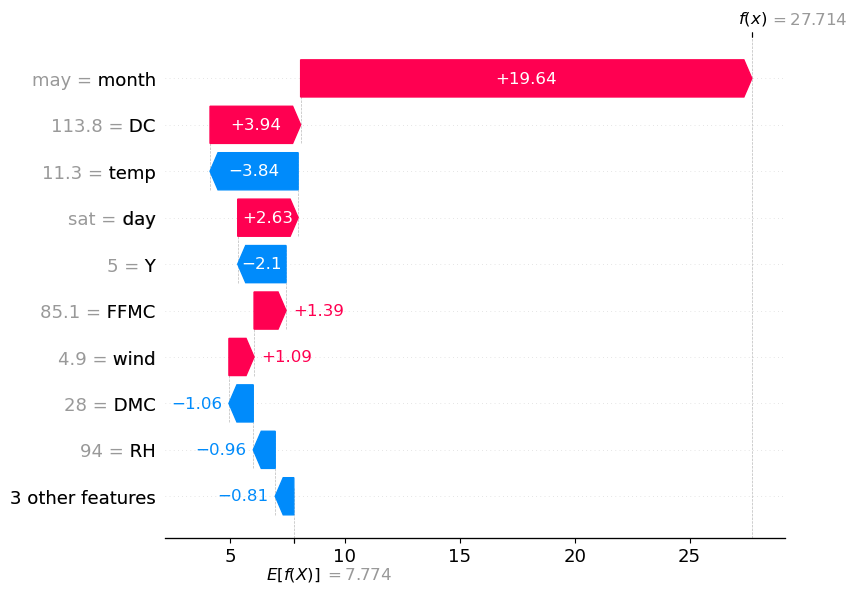

100%|██████████| 100/100 [00:44<00:00,  2.27it/s]


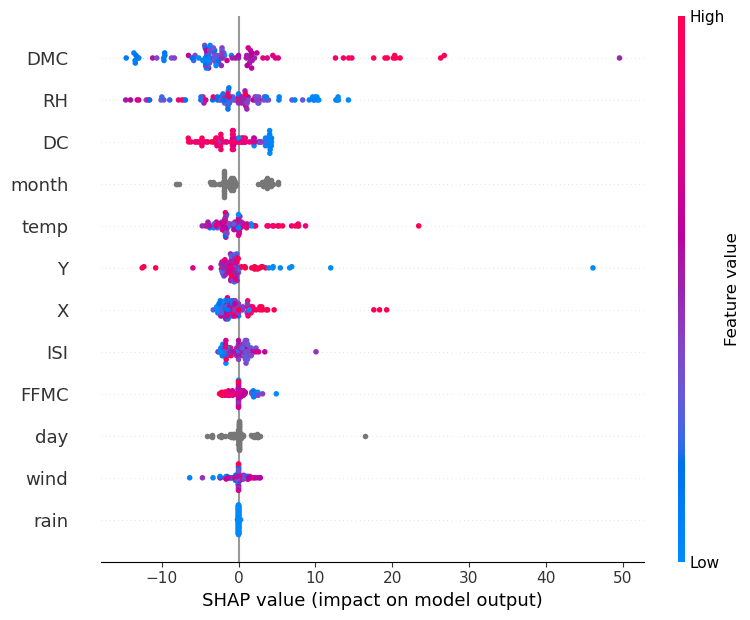

In [57]:
obs_index = 0
X_obs = X_test.iloc[[obs_index]]  # keep as DataFrame

# Calculate SHAP values for this observation
shap_values = explainer.shap_values(X_obs)

# Plot waterfall plot to see feature contributions
shap.plots.waterfall(shap.Explanation(values=shap_values[0], 
                                     base_values=explainer.expected_value,
                                     data=X_obs.iloc[0]))
plt.show()

X_train_sample = shap.sample(X_train, 100)  # sample 100 rows for speed
shap_values_train = explainer.shap_values(X_train_sample)

# Summary plot: global feature importance
shap.summary_plot(shap_values_train, X_train_sample)



*(Answer here.)*

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.